In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pickle, copy, random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)
beh = [[np.hstack((beh[mi][di][:, :3], beh[mi][di][:, 5:] / 40)) for di in range(3)] for mi in range(6)]
with open("h_spike.pkl", "rb") as f:
    h = pickle.load(f)
h = [[h[mi][di].astype(np.float32) for di in range(3)] for mi in range(6)]

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def _output_lstm(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _= self.lstm(x, (h0, c0))
        return out
    
    def forward(self, x):
        return self.sigmoid(self.linear(self._output_lstm(x)[:, -1, :]))
    
    def output_all(self, x):
        return self.sigmoid(self.linear(self._output_lstm(x)[0, :, :]))

In [5]:
class TimeSeriesDataSet(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data
        self.length = x_data.shape[0] - y_data.shape[0]
    
    def __len__(self):
        return self.x_data.shape[0] - self.length

    def __getitem__(self, index):
        return (self.x_data[index:index+self.length], self.y_data[index])

In [6]:
class BalancedLoss(nn.Module):
    def __init__(self, y):
        super().__init__()
        Yn = y <= 0.5
        Nn = Yn.sum()
        Np = (~Yn).sum()
        N = Nn + Np
        Sn = y[Yn].sum()
        Rn = np.square(y[Yn]).sum()
        Sp = y[~Yn].sum()
        Rp = np.square(y[~Yn]).sum()
        wp = ((Np + Nn) * (Nn -2*Sn)) / (8*(Sp*Rn - Sn*Rp) + 4*Nn*(Rp - Sp) + 4*Np*(Sn - Rn) + 2*(Sp*Nn -Sn*Np))
        self.wn = -wp * (Np - 2*Sp) / (Nn - 2*Sn)
        self.wp = wp

    def _calc_loss(self, outputs, targets):
        loss = torch.square(outputs - targets)
        loss[targets <= 0.5] *= self.wn
        loss[targets > 0.5] *= self.wp
        return loss

    def forward(self, outputs, targets):
        return self._calc_loss(outputs, targets).sum()

In [7]:
def fix_seeds(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [8]:
n_iter = 10
behs = ["Zone", "Lick", "Reward", "X", "Y"]
loss_save = np.zeros((6, 3, 1001, n_iter, 5, 3)) # mouse, day, epoch, iter, beh, all/train/valid
loss_save[:, :, :, :, :] = np.inf
succ_fail_dec= []

fix_seeds()
for mi in range(6):
    succ_fail_dec_s = []
    for di in range(3):
        succ_fail_dec_ss = []
        x = h[mi][di]
        y_all = beh[mi][di]
        N = y_all.shape[0]
        N_part = N // 4
        Nt = N_part * 2
        Nv = N - Nt
        for bi in range(5):
            y = beh[mi][di][:, bi:bi+1]
            criterion = BalancedLoss(y)
            for i in range(n_iter):
                succ_fail_dec_sss = []
                print("Mouse ID: {}, {}, Decoded Behavior: {} | iter: {}".format(mi+1, to_day(di), behs[bi], i+1))
                dataset = TimeSeriesDataSet(x[N_part:3*N_part+49, :], y[N_part:3*N_part, :])
                dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
                model = LSTMModel(x.shape[1], 8, 1, 2)
                model.cuda()
                optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

                x_cuda, y_cuda = torch.from_numpy(x).unsqueeze(0).cuda(), torch.from_numpy(y).cuda()

                def calc_loss():
                    model.eval()
                    output = model.output_all(x_cuda)[48:-1]
                    loss_raw = criterion._calc_loss(output, y_cuda)
                    loss_all = loss_raw.sum().item()
                    loss_train = loss_raw[N_part:N_part*3].sum().item()
                    loss_valid = loss_all - loss_train
                    if bi == 2:
                        succ_fail_dec_sss.append([
                            output[(y_all[:, 1] == 1) & (y_all[:, 2] == 0), 0].detach().cpu().numpy(), 
                            output[y_all[:, 2] == 1, 0].detach().cpu().numpy()])
                    return loss_all / N, loss_train / Nt, loss_valid / Nv

                la, lt, lv = calc_loss()
                loss_save[mi, di, 0, i, bi, :] = [la, lt, lv]
                lv_min = lv
                count = 0
                print("Epoch: 0 | Training Loss: {:.3f}, Validation Loss: {:.3f}".format(lt, lv))
                for epoch in range(1000):
                    for inputs, targets in dataloader:
                        model.train()
                        inputs, targets = inputs.cuda(), targets.cuda()
                        optimizer.zero_grad()
                        outputs = model(inputs)
                        loss = criterion(outputs, targets)
                        loss.backward()
                        optimizer.step()
                    la, lt, lv = calc_loss()
                    loss_save[mi, di, epoch+1, i, bi, :] = [la, lt, lv]
                    print("Epoch: {} | Training Loss: {:.3f}, Validation Loss: {:.3f}".format(epoch+1, lt, lv))
                    if lv < lv_min:
                        lv_min = lv
                        count = 0
                    else:
                        if epoch >= 50:
                            count += 1
                            if count >= 10:
                                break
                if bi == 2:
                    succ_fail_dec_ss.append(succ_fail_dec_sss)
        succ_fail_dec_s.append(succ_fail_dec_ss)
    succ_fail_dec.append(succ_fail_dec_s)
    with open("loss_save.pkl", "wb") as f:
        pickle.dump(loss_save, f)
    with open("succ_fail_dec.pkl", "wb") as f:
        pickle.dump(succ_fail_dec, f)

Mouse ID: 1, Day1, Decoded Behavior: Zone | iter: 1
Epoch: 0 | Training Loss: 0.230, Validation Loss: 0.273
Epoch: 1 | Training Loss: 0.229, Validation Loss: 0.273
Epoch: 2 | Training Loss: 0.229, Validation Loss: 0.273
Epoch: 3 | Training Loss: 0.229, Validation Loss: 0.273
Epoch: 4 | Training Loss: 0.228, Validation Loss: 0.273
Epoch: 5 | Training Loss: 0.227, Validation Loss: 0.273
Epoch: 6 | Training Loss: 0.225, Validation Loss: 0.272
Epoch: 7 | Training Loss: 0.221, Validation Loss: 0.269
Epoch: 8 | Training Loss: 0.215, Validation Loss: 0.264
Epoch: 9 | Training Loss: 0.207, Validation Loss: 0.258
Epoch: 10 | Training Loss: 0.199, Validation Loss: 0.252
Epoch: 11 | Training Loss: 0.192, Validation Loss: 0.245
Epoch: 12 | Training Loss: 0.187, Validation Loss: 0.244
Epoch: 13 | Training Loss: 0.184, Validation Loss: 0.244
Epoch: 14 | Training Loss: 0.180, Validation Loss: 0.241
Epoch: 15 | Training Loss: 0.177, Validation Loss: 0.242
Epoch: 16 | Training Loss: 0.175, Validation L

In [9]:
def output_all(mi, di, bi, seed=0):
    fix_seeds(seed)
    
    x = h[mi][di]
    y_all = beh[mi][di]
    N = y_all.shape[0]
    N_part = N // 4
    Nt = N_part * 2
    Nv = N - Nt
    y = beh[mi][di][:, bi:bi+1]
    criterion = BalancedLoss(y)
    dataset = TimeSeriesDataSet(x[N_part:3*N_part+49, :], y[N_part:3*N_part, :])
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
    model = LSTMModel(x.shape[1], 8, 1, 2)
    model.cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    x_cuda, y_cuda = torch.from_numpy(x).unsqueeze(0).cuda(), torch.from_numpy(y).cuda()
    t = x_cuda.shape[1]
    save = np.zeros((t, 1001))
    lvs = np.zeros(1001)
    lvs[:] = np.inf

    def calc_loss(i):
        model.eval()
        output = model.output_all(x_cuda)
        loss_raw = criterion._calc_loss(output[48:-1], y_cuda)
        loss_all = loss_raw.sum().item()
        loss_train = loss_raw[N_part:N_part*3].sum().item()
        loss_valid = loss_all - loss_train
        save[:, i] = output.detach().cpu().numpy()[:, 0]
        lvs[i] = loss_valid / Nv
        return loss_all / N, loss_train / Nt, lvs[i]

    la, lt, lv = calc_loss(0)
    lv_min = lv
    count = 0
    print("Epoch: 0 | Training Loss: {:.3f}, Validation Loss: {:.3f}".format(lt, lv))
    for epoch in range(1000):
        for inputs, targets in dataloader:
            model.train()
            inputs, targets = inputs.cuda(), targets.cuda()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        la, lt, lv = calc_loss(epoch+1)
        print("Epoch: {} | Training Loss: {:.3f}, Validation Loss: {:.3f}".format(epoch+1, lt, lv))
        if lv < lv_min:
            lv_min = lv
            count = 0
        else:
            if epoch >= 50:
                count += 1
                if count >= 10:
                    break
    return save[48:-1, lvs.argmin()]

In [10]:
print("Mouse ID: 5, Day1, Reward")
out_day1 = output_all(4, 0, 2, 0)
print("Mouse ID: 5, Day6, Reward")
out_day6 = output_all(4, 2, 2, 1)

Mouse ID: 5, Day1, Reward
Epoch: 0 | Training Loss: 0.245, Validation Loss: 0.258
Epoch: 1 | Training Loss: 0.245, Validation Loss: 0.258
Epoch: 2 | Training Loss: 0.244, Validation Loss: 0.257
Epoch: 3 | Training Loss: 0.244, Validation Loss: 0.257
Epoch: 4 | Training Loss: 0.243, Validation Loss: 0.256
Epoch: 5 | Training Loss: 0.242, Validation Loss: 0.255
Epoch: 6 | Training Loss: 0.240, Validation Loss: 0.254
Epoch: 7 | Training Loss: 0.239, Validation Loss: 0.252
Epoch: 8 | Training Loss: 0.235, Validation Loss: 0.249
Epoch: 9 | Training Loss: 0.230, Validation Loss: 0.244
Epoch: 10 | Training Loss: 0.220, Validation Loss: 0.236
Epoch: 11 | Training Loss: 0.207, Validation Loss: 0.225
Epoch: 12 | Training Loss: 0.196, Validation Loss: 0.217
Epoch: 13 | Training Loss: 0.187, Validation Loss: 0.211
Epoch: 14 | Training Loss: 0.180, Validation Loss: 0.203
Epoch: 15 | Training Loss: 0.173, Validation Loss: 0.197
Epoch: 16 | Training Loss: 0.166, Validation Loss: 0.190
Epoch: 17 | Tra

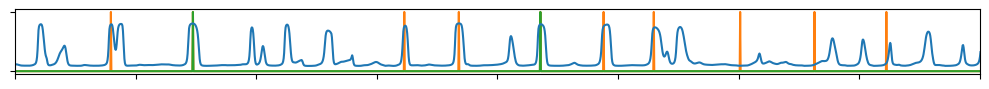

In [11]:
plt.figure(figsize=(10, 1))
plt.plot(beh[4][0][:, 1], color="C1")
plt.plot(beh[4][0][:, 2], color="C2")
plt.plot(out_day1, color="C0")
plt.xlim(10000, 12000)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig7/fig7d_Day1.png")

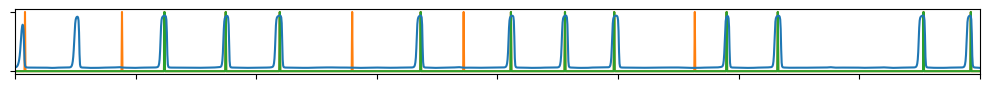

In [12]:
plt.figure(figsize=(10, 1))
plt.plot(beh[4][2][:, 1], color="C1")
plt.plot(beh[4][2][:, 2], color="C2")
plt.plot(out_day6, color="C0")
plt.xlim(4000, 6000)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig7/fig7d_Day6.png")